# PHẦN 2. PHÂN TÍCH PHÂN PHỐI XÁC SUẤT

## Bối cảnh và mục tiêu

Nhu cầu thuê xe theo giờ biến động theo thời điểm trong ngày, loại ngày và điều kiện thời tiết. Phần này tiếp nối kết quả EDA để trả lời câu hỏi: dữ liệu quan sát có hình dạng phân phối nào, và phân phối lý thuyết nào có thể mô tả dữ liệu một cách hợp lý?

Notebook sử dụng dữ liệu đã được xử lý ở Phần 1, nhưng không thay đổi dataset gốc. Các giá trị thời tiết `temp` và `hum` được giữ ở thang chuẩn hóa 0–1. Tổng lượt thuê `cnt` được xem là biến đếm; `casual` và `registered` chỉ được dùng để kiểm tra tính nhất quán, không dùng làm biến giải thích cho mô hình dự báo.

## Câu hỏi nghiên cứu

1. `cnt` có lệch phải, đuôi dài và over-dispersion hay không?
2. Poisson, Negative Binomial, Normal hay Log-normal mô tả `cnt` tốt hơn theo đồ thị và AIC/BIC?
3. `temp` và `hum` gần với Normal hay Beta hơn trên miền giá trị chuẩn hóa?
4. Phân phối và mức trung tâm của `cnt` có khác nhau giữa ngày làm việc và ngày nghỉ không?

## Quy trình phân tích

| Bước | Nội dung | Mục đích |
| --- | --- | --- |
| 2.1 | Xác nhận dữ liệu và thống kê mô tả | Kiểm tra đầu vào, độ lệch và độ phân tán |
| 2.2 | Phân phối thực nghiệm của `cnt` | Nhận diện đuôi phải, cực trị và tỷ lệ tích lũy |
| 2.3 | Fit các phân phối cho `cnt` | So sánh mô hình cho biến đếm và baseline liên tục |
| 2.4 | Phân phối `temp`, `hum` | Đối chiếu Normal và Beta |
| 2.5 | Phân tích theo `workingday` | Cung cấp ngữ cảnh cho phần kiểm định giả thuyết |
| 2.6 | Kết luận và bàn giao | Ghi rõ quyết định, hạn chế và lưu ý downstream |

Các kiểm định goodness-of-fit chỉ là bằng chứng bổ sung. Với cỡ mẫu lớn và dữ liệu theo giờ có tự tương quan, không kết luận chỉ dựa trên p-value.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

candidate_paths = [
    Path("../EDA/cleaned_data/hour_cleaned.csv"),
    Path("EDA/cleaned_data/hour_cleaned.csv"),
    Path.cwd().parent / "EDA/cleaned_data/hour_cleaned.csv",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy EDA/cleaned_data/hour_cleaned.csv")

df = pd.read_csv(DATA_PATH)
unnamed_columns = [column for column in df.columns if column.lower().startswith("unnamed")]
df = df.drop(columns=unnamed_columns)
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")

print(f"Đầu vào: {DATA_PATH.resolve()}")
print(f"Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} biến")
print(f"Cột index dư thừa đã loại: {unnamed_columns or 'không có'}")
print(f"Giá trị thiếu: {int(df.isna().sum().sum())}")
display(df.head())

Đầu vào: C:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\EDA\cleaned_data\hour_cleaned.csv
Kích thước: 17,379 dòng x 17 biến
Cột index dư thừa đã loại: không có
Giá trị thiếu: 0


Đầu vào: C:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\EDA\cleaned_data\hour_cleaned.csv
Kích thước: 17,379 dòng x 17 biến
Cột index dư thừa đã loại: không có
Giá trị thiếu: 0


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [26]:
quality_checks = {
    "Số dòng": len(df),
    "Số cột sau khi loại index": df.shape[1],
    "Số ô thiếu": int(df.isna().sum().sum()),
    "Số dòng trùng hoàn toàn": int(df.duplicated().sum()),
    "Số cặp dteday-hr trùng": int(df.duplicated(["dteday", "hr"]).sum()),
    "cnt khác casual + registered": int((df["cnt"] != df["casual"] + df["registered"]).sum()),
    "cnt bằng 0": int((df["cnt"] == 0).sum()),
}
display(pd.Series(quality_checks, name="Giá trị"))

range_checks = pd.DataFrame({
    "Min": df[["cnt", "temp", "hum"]].min(),
    "Max": df[["cnt", "temp", "hum"]].max(),
    "Số giá trị khác nhau": df[["cnt", "temp", "hum"]].nunique(),
})
display(range_checks)

print("Khoảng thời gian:", df["dteday"].min().date(), "đến", df["dteday"].max().date())
print("Các giá trị hum = 0 sau tiền xử lý:", int((df["hum"] == 0).sum()))

Số dòng                         17379
Số cột sau khi loại index          17
Số ô thiếu                          0
Số dòng trùng hoàn toàn             0
Số cặp dteday-hr trùng              0
cnt khác casual + registered        0
cnt bằng 0                          0
Name: Giá trị, dtype: int64

,Min,Max,Số giá trị khác nhau
cnt,1.00,977.0,869
temp,0.02,1.0,50
hum,0.08,1.0,97


Khoảng thời gian: 2011-01-01 đến 2012-12-31
Các giá trị hum = 0 sau tiền xử lý: 0


**Nhận xét kiểm tra đầu vào.** Dữ liệu sau EDA vẫn có 17,379 dòng; không có ô thiếu, dòng trùng hoặc cặp ngày–giờ trùng. Ràng buộc `cnt = casual + registered` được kiểm tra để bảo đảm biến mục tiêu không bị sai do lỗi xuất file. `cnt` không có giá trị 0, trong khi `hum = 0` đã được xử lý ở Phần 1; vì vậy các kết quả dưới đây phản ánh phiên bản dữ liệu sạch mà nhóm đã thống nhất.

## 2.1. Xác nhận dữ liệu và thống kê mô tả

**Mục tiêu.** Xác nhận rằng notebook đang dùng đúng phiên bản dữ liệu sau EDA, kiểm tra các ràng buộc cơ bản và mô tả mức trung tâm, độ phân tán, độ lệch của ba biến được chọn.

**Lý do chọn biến.** `cnt` là biến mục tiêu và là biến đếm quan trọng nhất. `temp` được chọn vì EDA cho thấy có tương quan dương đáng chú ý với `cnt` và hình dạng gần đối xứng. `hum` được chọn vì có tương quan âm với `cnt`, đồng thời giúp so sánh một biến gần đối xứng nhưng bị giới hạn trong khoảng 0–1.

**Quy ước dữ liệu.** `cnt` được đo bằng lượt thuê/giờ. `temp` và `hum` là giá trị chuẩn hóa, không phải độ C hay phần trăm ở thang gốc. Cột index được sinh khi xuất CSV chỉ là cột kỹ thuật và không được xem là biến phân tích.

In [27]:
analysis_columns = ["cnt", "temp", "hum"]
summary = df[analysis_columns].describe(percentiles=[0.25, 0.5, 0.75]).T
summary["IQR"] = summary["75%"] - summary["25%"]
summary["skewness"] = df[analysis_columns].skew()
summary["kurtosis"] = df[analysis_columns].kurtosis()
summary["variance_to_mean"] = df[analysis_columns].var() / df[analysis_columns].mean()
summary.round(4)

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis,variance_to_mean
cnt,17379.0,189.4631,181.3876,1.00,40.00,142.00,281.00,977.0,241.00,1.2774,1.4172,173.6563
temp,17379.0,0.4970,0.1926,0.02,0.34,0.50,0.66,1.0,0.32,-0.0060,-0.9418,0.0746
hum,17379.0,0.6281,0.1917,0.08,0.48,0.63,0.78,1.0,0.30,-0.0828,-0.9119,0.0585


**Nhận xét Bảng 2.1.** `cnt` có mean lớn hơn median và skewness dương, cho thấy một số giờ có nhu cầu rất cao kéo mean lên. Tỷ số variance/mean lớn hơn rất nhiều so với 1 là dấu hiệu dữ liệu không phù hợp với giả định equidispersion của Poisson đơn giản. Ngược lại, `temp` và `hum` có skewness gần 0, nên hình dạng của chúng gần đối xứng hơn `cnt`.

Các chỉ số này chỉ mô tả mẫu dữ liệu hiện có. Chúng chưa cho biết tác động riêng của thời tiết vì `cnt` còn thay đổi theo `hr`, năm, mùa và `workingday`.

## 2.2. Phân phối thực nghiệm của `cnt`

**Mục tiêu.** Quan sát trực tiếp hình dạng phân phối của nhu cầu thuê xe theo giờ trước khi áp đặt một phân phối lý thuyết.

**Phương pháp và lý do chọn biểu đồ.**

- Histogram kết hợp KDE cho biết vùng tập trung, mode và đuôi phải của `cnt`.
- Đường mean và median giúp nhận diện nhanh độ lệch phải.
- ECDF cho biết tỷ lệ số giờ có nhu cầu không vượt quá một mức cụ thể.
- Boxplot tóm tắt median, IQR và các giá trị cực trị; phù hợp để nhìn độ phân tán nhưng không thay thế histogram khi cần xem hình dạng.

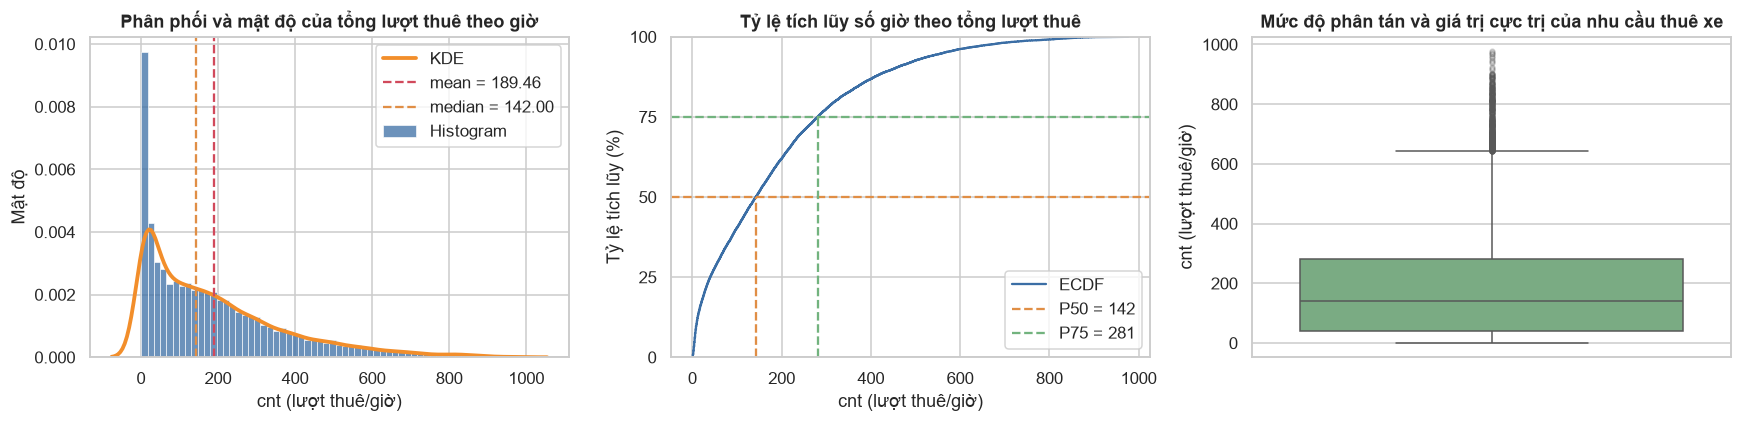

Mean = 189.46; median = 142.00; skewness = 1.2774
Variance/mean = 173.66
Tỷ lệ cnt <= 5: 6.22%; tỷ lệ cnt > 642.5: 2.91%


In [28]:
cnt = df["cnt"].astype(int)
median_cnt = cnt.quantile(0.50)
q3_cnt = cnt.quantile(0.75)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(cnt, bins=60, stat="density", kde=False, ax=axes[0], color="#3b6ea5", label="Histogram")
sns.kdeplot(cnt, ax=axes[0], color="#f28e2b", linewidth=2.5, label="KDE")
axes[0].axvline(cnt.mean(), color="#d1495b", ls="--", label=f"mean = {cnt.mean():.2f}")
axes[0].axvline(median_cnt, color="#e08e45", ls="--", label=f"median = {median_cnt:.2f}")
axes[0].set_title("Phân phối và mật độ của tổng lượt thuê theo giờ")
axes[0].set_xlabel("cnt (lượt thuê/giờ)")
axes[0].set_ylabel("Mật độ")
axes[0].legend()

ecdf_y = np.arange(1, len(cnt) + 1) / len(cnt) * 100
ecdf_x = np.sort(cnt)
axes[1].step(ecdf_x, ecdf_y, where="post", color="#3b6ea5", label="ECDF")
axes[1].axhline(50, color="#e08e45", ls="--", linewidth=1.5)
axes[1].axvline(median_cnt, ymin=0, ymax=0.5, color="#e08e45", ls="--", linewidth=1.5, label=f"P50 = {median_cnt:.0f}")
axes[1].axhline(75, color="#72b37e", ls="--", linewidth=1.5)
axes[1].axvline(q3_cnt, ymin=0, ymax=0.75, color="#72b37e", ls="--", linewidth=1.5, label=f"P75 = {q3_cnt:.0f}")
axes[1].set_title("Tỷ lệ tích lũy số giờ theo tổng lượt thuê")
axes[1].set_xlabel("cnt (lượt thuê/giờ)")
axes[1].set_ylabel("Tỷ lệ tích lũy (%)")
axes[1].set_ylim(0, 100)
axes[1].set_yticks([0, 25, 50, 75, 100])
axes[1].legend(loc="lower right")

sns.boxplot(y=cnt, ax=axes[2], color="#72b37e", flierprops={"marker": ".", "alpha": 0.25})
axes[2].set_title("Mức độ phân tán và giá trị cực trị của nhu cầu thuê xe")
axes[2].set_ylabel("cnt (lượt thuê/giờ)")
plt.tight_layout()
plt.show()

print(f"Mean = {cnt.mean():.2f}; median = {cnt.median():.2f}; skewness = {cnt.skew():.4f}")
print(f"Variance/mean = {cnt.var() / cnt.mean():.2f}")
print(f"Tỷ lệ cnt <= 5: {(cnt <= 5).mean():.2%}; tỷ lệ cnt > 642.5: {(cnt > 642.5).mean():.2%}")

In [29]:
fig.savefig("assets/Hinh2.1.png", dpi=180, bbox_inches="tight")

In [30]:
cnt_shape_table = pd.DataFrame({
    "Chỉ số": ["Q1", "Median", "Q3", "IQR", "Skewness", "Kurtosis", "Variance/mean"],
    "Giá trị": [
        cnt.quantile(0.25),
        cnt.median(),
        cnt.quantile(0.75),
        cnt.quantile(0.75) - cnt.quantile(0.25),
        cnt.skew(),
        cnt.kurtosis(),
        cnt.var() / cnt.mean(),
    ],
})
display(cnt_shape_table.round(4))

log_cnt = np.log1p(cnt)
print(f"Skewness của cnt: {cnt.skew():.4f}")
print(f"Skewness của log1p(cnt): {log_cnt.skew():.4f}")
print("Diễn giải: log1p được kiểm tra để đánh giá hình dạng, không mặc định là biến đổi cuối cùng cho mô hình.")

,Chỉ số,Giá trị
0,Q1,40.0000
1,Median,142.0000
2,Q3,281.0000
3,IQR,241.0000
4,Skewness,1.2774
5,Kurtosis,1.4172
6,Variance/mean,173.6563


Skewness của cnt: 1.2774
Skewness của log1p(cnt): -0.8182
Diễn giải: log1p được kiểm tra để đánh giá hình dạng, không mặc định là biến đổi cuối cùng cho mô hình.


**Kiểm tra biến đổi log1p.** `log1p` giảm ảnh hưởng của đuôi phải nhưng không tự động làm dữ liệu trở thành Normal. Nếu skewness sau biến đổi bị đảo sang trái hoặc Q–Q plot vẫn cong rõ, việc biến đổi mục tiêu phải được quyết định theo mục tiêu mô hình ở các phần sau.

**Nhận xét Hình 2.1.** Histogram tập trung nhiều ở vùng nhu cầu thấp và kéo dài về phía phải đến 977 lượt/giờ. Mean 189.46 nằm cao hơn median 142.00, phù hợp với skewness 1.2774. ECDF cho thấy khoảng một nửa số giờ có không quá 142 lượt thuê, trong khi một tỷ lệ nhỏ các giờ cao điểm tạo ra phần đuôi dài. Boxplot cho thấy các giá trị cao không nên tự động xóa vì EDA đã chỉ ra chúng tập trung ở các giờ cao điểm hợp lý.

Tỷ số variance/mean bằng 173.66 cho thấy phân phối gộp của `cnt` có over-dispersion rất mạnh so với Poisson. Tuy nhiên, tỷ số này cũng chịu ảnh hưởng bởi việc gộp nhiều cơ chế khác nhau: giờ thấp điểm và cao điểm, ngày làm việc và ngày nghỉ, hai năm và các điều kiện thời tiết khác nhau.

## 2.3. So sánh các phân phối lý thuyết cho `cnt`

**Mục tiêu.** Kiểm tra các họ phân phối thường được cân nhắc cho biến đếm lệch phải, đồng thời dùng Normal và Log-normal làm baseline liên tục để đối chiếu.

### Lý do chọn các phân phối

- **Poisson:** phù hợp với biến đếm không âm khi mean và variance xấp xỉ nhau. Với Poisson, tham số duy nhất là $\lambda = E[cnt]$.
- **Negative Binomial:** mở rộng Poisson bằng cách cho phép variance lớn hơn mean. Đây là ứng viên quan trọng vì `cnt` có variance/mean = 173.66.
- **Normal:** baseline đối xứng, hữu ích để cho thấy vì sao giả định chuẩn không mô tả tốt biến đếm lệch phải.
- **Log-normal:** baseline dương và lệch phải; được dùng để kiểm tra liệu một phân phối liên tục lệch phải có mô tả được đuôi của `cnt` tốt hơn Normal hay không.

### Tiêu chí so sánh

AIC và BIC cân bằng giữa độ phù hợp và số tham số; giá trị thấp hơn là tốt hơn khi các mô hình được fit trên cùng dữ liệu. Các tiêu chí này không biến một mô hình liên tục thành mô hình đếm, vì vậy phải đọc cùng histogram, Q–Q plot và bản chất của biến `cnt`.

,Phân phối,Likelihood,Tham số,Log-likelihood,AIC,BIC
0,Poisson,discrete PMF,mu=189.4631,-1501246.101,3002494.202,3002501.965
1,Negative Binomial,discrete PMF,size=0.8447; p=0.004439,-108398.219,216800.438,216815.964
2,Normal,continuous PDF,loc=189.4631; scale=181.3824,-115041.089,230086.178,230101.704
3,Log-normal,continuous PDF,shape=1.4861; scale=93.3244,-110377.023,220758.045,220773.571


,Phân phối,Likelihood,Tham số,Log-likelihood,AIC,BIC
0,Poisson,discrete PMF,mu=189.4631,-1501246.101,3002494.202,3002501.965
1,Negative Binomial,discrete PMF,size=0.8447; p=0.004439,-108398.219,216800.438,216815.964
2,Normal,continuous PDF,loc=189.4631; scale=181.3824,-115041.089,230086.178,230101.704
3,Log-normal,continuous PDF,shape=1.4861; scale=93.3244,-110377.023,220758.045,220773.571


NB optimizer success: True; message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
AIC difference (Poisson - NB, both discrete): 2,785,693.764
ln(n) for BIC: 9.7630


,Phân phối,Likelihood,Tham số,Log-likelihood,AIC,BIC
0,Poisson,discrete PMF,mu=189.4631,-1501246.101,3002494.202,3002501.965
1,Negative Binomial,discrete PMF,size=0.8447; p=0.004439,-108398.219,216800.438,216815.964
2,Normal,continuous PDF,loc=189.4631; scale=181.3824,-115041.089,230086.178,230101.704
3,Log-normal,continuous PDF,shape=1.4861; scale=93.3244,-110377.023,220758.045,220773.571


NB optimizer success: True; message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
AIC difference (Poisson - NB, both discrete): 2,785,693.764
ln(n) for BIC: 9.7630


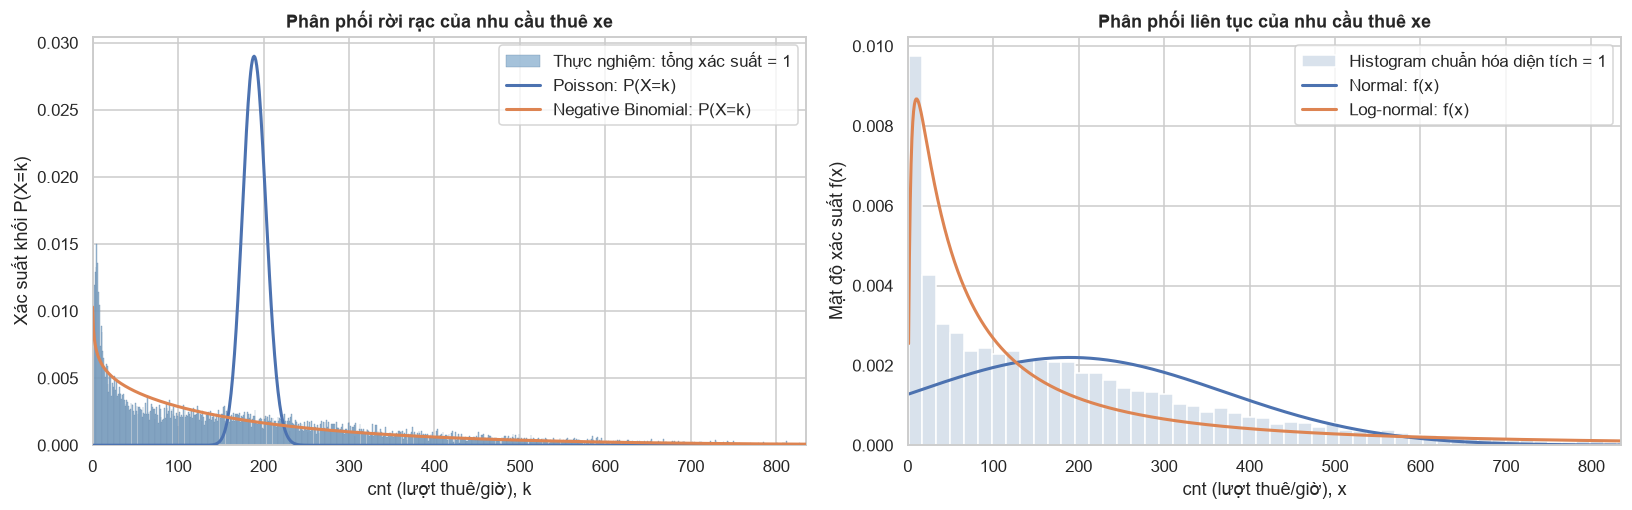

In [3]:
def information_criteria(log_likelihood, parameter_count, sample_size):
    aic = 2 * parameter_count - 2 * log_likelihood
    bic = parameter_count * np.log(sample_size) - 2 * log_likelihood
    return aic, bic

n = len(cnt)
mu = cnt.mean()
variance = cnt.var()
poisson_parameters = {"mu": mu}
poisson_log_likelihood = stats.poisson.logpmf(cnt, mu=mu).sum()
poisson_aic, poisson_bic = information_criteria(poisson_log_likelihood, 1, n)

if variance <= mu:
    raise ValueError("Variance của cnt không lớn hơn mean; không thể ước lượng NB theo MoM.")
nb_size = mu ** 2 / (variance - mu)
nb_probability = nb_size / (nb_size + mu)
nb_parameters = {"size": nb_size, "probability": nb_probability}
nb_log_likelihood = stats.nbinom.logpmf(cnt, nb_size, nb_probability).sum()
nb_aic, nb_bic = information_criteria(nb_log_likelihood, 2, n)

normal_loc, normal_scale = stats.norm.fit(cnt)
normal_log_likelihood = stats.norm.logpdf(cnt, normal_loc, normal_scale).sum()
normal_aic, normal_bic = information_criteria(normal_log_likelihood, 2, n)

lognormal_shape, lognormal_loc, lognormal_scale = stats.lognorm.fit(cnt, floc=0)
lognormal_log_likelihood = stats.lognorm.logpdf(cnt, lognormal_shape, lognormal_loc, lognormal_scale).sum()
lognormal_aic, lognormal_bic = information_criteria(lognormal_log_likelihood, 2, n)

fit_table = pd.DataFrame([
    ("Poisson", f"mu={mu:.4f}", poisson_log_likelihood, poisson_aic, poisson_bic),
    ("Negative Binomial", f"size={nb_size:.4f}; p={nb_probability:.4f}", nb_log_likelihood, nb_aic, nb_bic),
    ("Normal", f"loc={normal_loc:.4f}; scale={normal_scale:.4f}", normal_log_likelihood, normal_aic, normal_bic),
    ("Log-normal", f"shape={lognormal_shape:.4f}; scale={lognormal_scale:.4f}", lognormal_log_likelihood, lognormal_aic, lognormal_bic),
], columns=["Phân phối", "Tham số", "Log-likelihood", "AIC", "BIC"])
display(fit_table.round(3))

x_grid = np.arange(0, int(cnt.max()) + 1)
density_grid = np.linspace(max(0.01, cnt.min()), cnt.max(), 1000)
discrete_edges = np.arange(-0.5, int(cnt.max()) + 1.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].hist(
    cnt,
    bins=discrete_edges,
    weights=np.ones(n) / n,
    color="#8fb3d1",
    edgecolor="#5b7fa3",
    linewidth=0.25,
    alpha=0.8,
    rwidth=0.95,
    label="Thực nghiệm: tổng xác suất = 1",
)
axes[0].plot(x_grid, stats.poisson.pmf(x_grid, mu), label="Poisson: P(X=k)", lw=2, zorder=3)
axes[0].plot(x_grid, stats.nbinom.pmf(x_grid, nb_size, nb_probability), label="Negative Binomial: P(X=k)", lw=2, zorder=3)
axes[0].set_xlim(0, cnt.quantile(0.995))
axes[0].set_title("Phân phối rời rạc của nhu cầu thuê xe")
axes[0].set_xlabel("cnt (lượt thuê/giờ), k")
axes[0].set_ylabel("Xác suất khối P(X=k)")
axes[0].legend()

axes[1].hist(cnt, bins=60, density=True, color="#d9e2ec", edgecolor="white", label="Histogram chuẩn hóa diện tích = 1")
axes[1].plot(density_grid, stats.norm.pdf(density_grid, normal_loc, normal_scale), label="Normal: f(x)", lw=2)
axes[1].plot(density_grid, stats.lognorm.pdf(density_grid, lognormal_shape, lognormal_loc, lognormal_scale), label="Log-normal: f(x)", lw=2)
axes[1].set_xlim(0, cnt.quantile(0.995))
axes[1].set_title("Phân phối liên tục của nhu cầu thuê xe")
axes[1].set_xlabel("cnt (lượt thuê/giờ), x")
axes[1].set_ylabel("Mật độ xác suất f(x)")
axes[1].legend()

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

In [45]:
fig.savefig("assets/Hinh2.2.png", dpi=180, bbox_inches="tight")

### Q–Q plot và kiểm tra goodness-of-fit

Q–Q plot so sánh các quantile thực nghiệm với quantile lý thuyết. Nếu các điểm nằm gần đường chéo, phân phối lý thuyết mô tả tương đối tốt vùng đó; độ cong ở hai đầu thường cho thấy sai lệch ở đuôi hoặc phần trung tâm.

Với `cnt`, Poisson và Negative Binomial là phân phối rời rạc nên được đánh giá chủ yếu bằng histogram, xác suất theo khoảng và AIC/BIC. KS được báo cáo cho Normal và Log-normal như một tham khảo, nhưng việc fit tham số trên cùng mẫu khiến p-value không phải kiểm định độc lập hoàn toàn. Với hơn 17,000 quan sát, p-value rất nhỏ có thể xuất hiện ngay cả khi sai lệch thực tế không lớn.

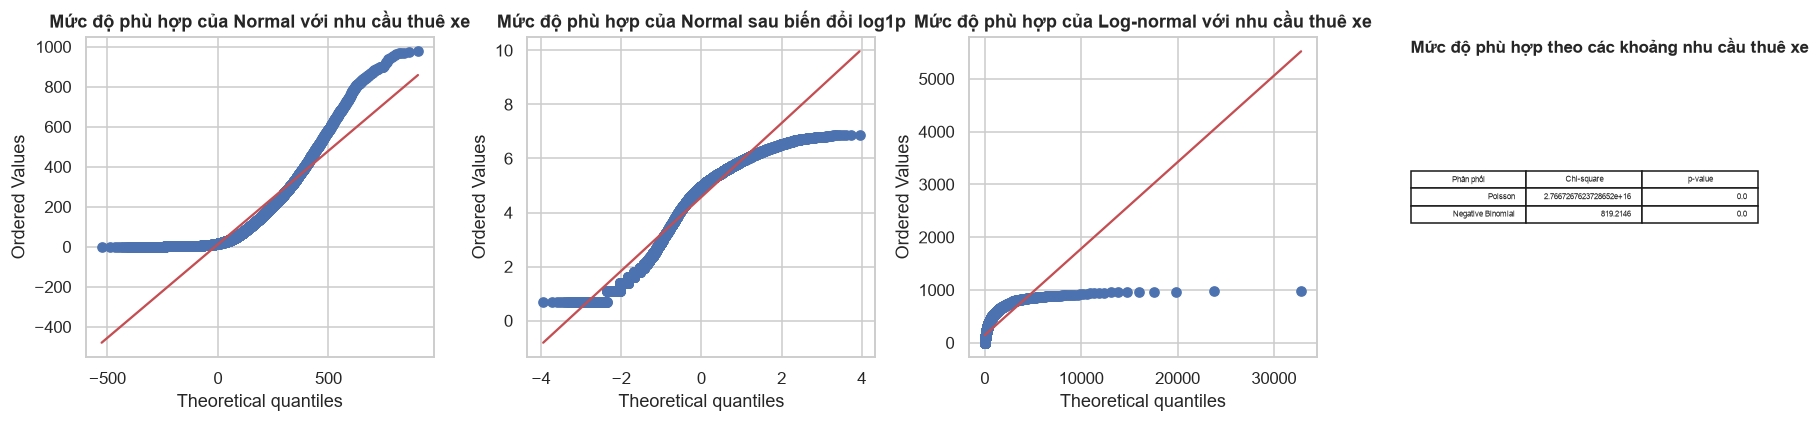

,Phân phối,KS statistic,p-value
0,Normal,0.1494,0.0
1,Log-normal,0.1183,0.0


Cảnh báo: expected counts rất nhỏ được đặt sàn 1e-9 để tránh underflow; với n lớn, KS/chi-square có thể bác bỏ sai lệch rất nhỏ.


In [33]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
stats.probplot(cnt, dist=stats.norm, sparams=(normal_loc, normal_scale), plot=axes[0])
axes[0].set_title("Mức độ phù hợp của Normal với nhu cầu thuê xe")
stats.probplot(np.log1p(cnt), dist=stats.norm, plot=axes[1])
axes[1].set_title("Mức độ phù hợp của Normal sau biến đổi log1p")
stats.probplot(cnt, dist=stats.lognorm, sparams=(lognormal_shape, lognormal_loc, lognormal_scale), plot=axes[2])
axes[2].set_title("Mức độ phù hợp của Log-normal với nhu cầu thuê xe")

group_edges = np.array([-0.5, 50.5, 100.5, 150.5, 250.5, 400.5, 650.5, cnt.max() + 0.5])
observed, _ = np.histogram(cnt, bins=group_edges)
poisson_expected = n * np.diff(stats.poisson.cdf(group_edges, mu))
nb_expected = n * np.diff(stats.nbinom.cdf(group_edges, nb_size, nb_probability))
chi_rows = []
for name, expected in [("Poisson", poisson_expected), ("Negative Binomial", nb_expected)]:
    expected = np.maximum(expected, 1e-9)
    expected *= observed.sum() / expected.sum()
    statistic, p_value = stats.chisquare(observed, expected)
    chi_rows.append((name, statistic, p_value))
chi_table = pd.DataFrame(chi_rows, columns=["Phân phối", "Chi-square", "p-value"])
axes[3].axis("off")
axes[3].text(0, 0.95, "Mức độ phù hợp theo các khoảng nhu cầu thuê xe", fontsize=11, fontweight="bold")
axes[3].table(cellText=chi_table.round(4).astype(str).values, colLabels=chi_table.columns, loc="center")
plt.tight_layout()
plt.show()

continuous_gof = pd.DataFrame([
    ("Normal", *stats.kstest(cnt, stats.norm.cdf, args=(normal_loc, normal_scale))),
    ("Log-normal", *stats.kstest(cnt, stats.lognorm.cdf, args=(lognormal_shape, lognormal_loc, lognormal_scale))),
], columns=["Phân phối", "KS statistic", "p-value"])
display(continuous_gof.round(4))
print("Cảnh báo: expected counts rất nhỏ được đặt sàn 1e-9 để tránh underflow; với n lớn, KS/chi-square có thể bác bỏ sai lệch rất nhỏ.")

In [34]:
fig.savefig("assets/Hinh2.3.png", dpi=180, bbox_inches="tight")

**Nhận xét Hình 2.3 và bảng goodness-of-fit.** Normal lệch rõ khỏi đường chéo vì không thể đồng thời mô tả vùng `cnt` thấp, trung tâm và đuôi phải. Log-normal bám phần đuôi tốt hơn Normal nhưng vẫn không tái hiện hoàn toàn cấu trúc rời rạc và sự pha trộn của các khung giờ. Negative Binomial được ưu tiên về mặt diễn giải vì vừa là phân phối đếm vừa cho phép over-dispersion.

Chi-square/KS có p-value rất nhỏ trong bối cảnh mẫu lớn. Vì vậy kết luận không phải là “một phân phối hoàn hảo”, mà là Negative Binomial là lựa chọn hợp lý hơn Poisson cho mô tả dữ liệu đếm này khi kết hợp bản chất biến, tỷ số variance/mean, đồ thị và AIC/BIC.

## 2.4. Phân phối của `temp` và `hum`

**Mục tiêu.** Đánh giá hình dạng của hai biến thời tiết liên tục đã chuẩn hóa và so sánh hai họ phân phối có ý nghĩa khác nhau:

- Normal kiểm tra mức độ gần đối xứng và khả năng dùng xấp xỉ chuẩn trong các phân tích sau.
- Beta phù hợp về mặt miền giá trị vì biến nằm trong khoảng 0–1, nhưng không nên chọn chỉ vì miền giá trị phù hợp.

**Cách fit Beta.** Phân phối Beta không nhận đúng giá trị biên 0 hoặc 1 trong mật độ thông thường. Notebook dùng một clipping rất nhỏ chỉ cho bước fit, không thay đổi dataframe gốc; quyết định này được ghi rõ để kết quả có thể tái lập.

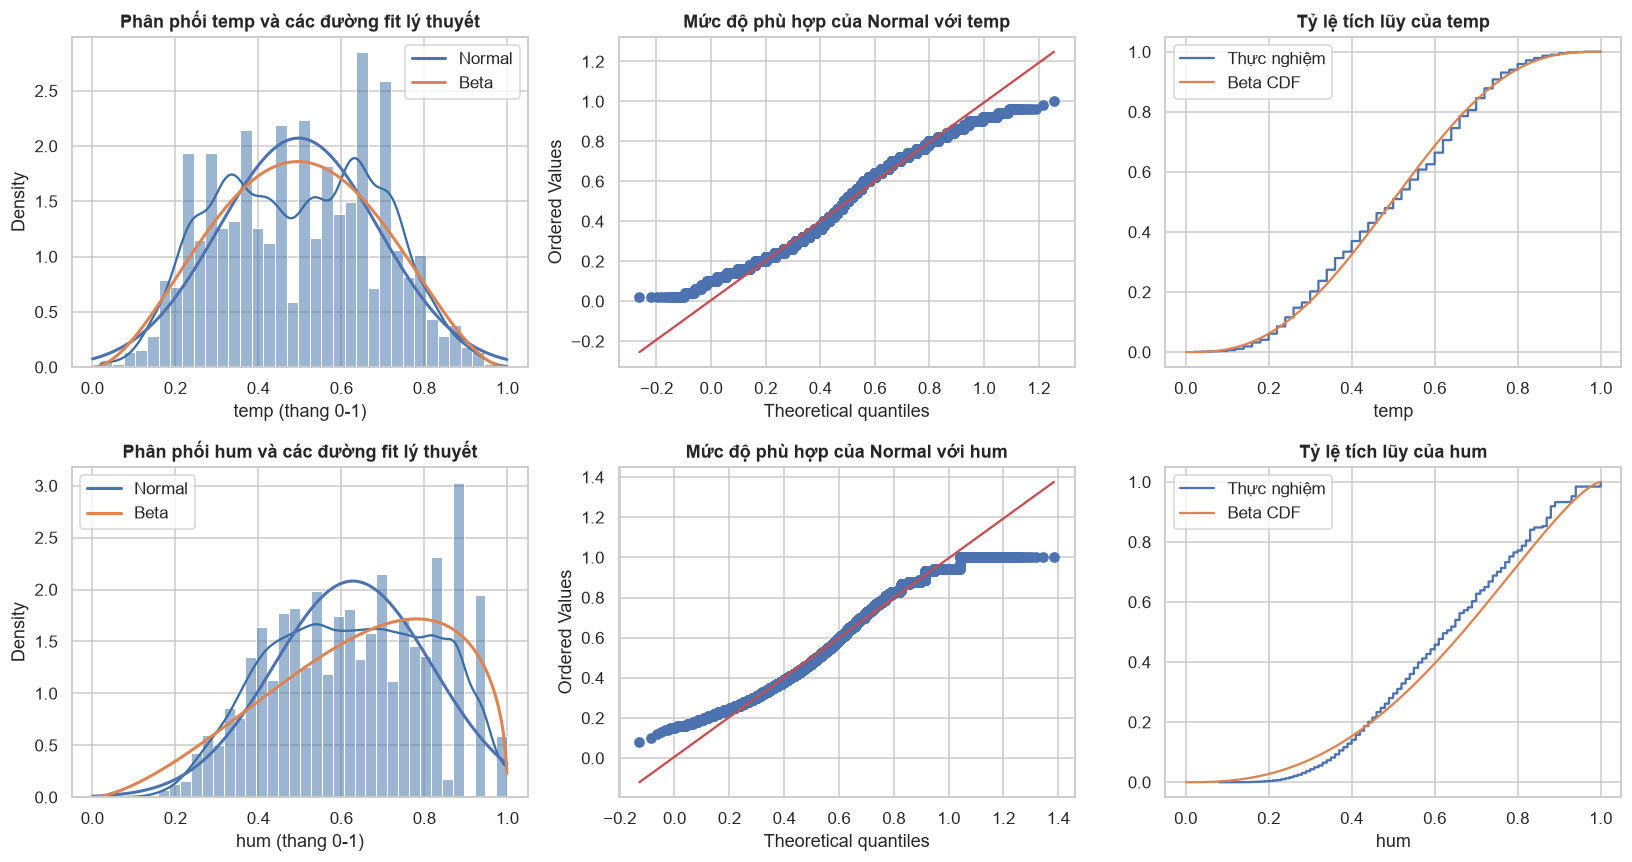

temp - so sánh AIC/BIC


,Phân phối,Tham số,AIC,BIC
0,Normal,loc=0.4970; scale=0.1926,-7936.739,-7921.212
1,Beta,a=2.9362; b=2.9728,-9102.191,-9086.665


hum - so sánh AIC/BIC


,Phân phối,Tham số,AIC,BIC
0,Normal,loc=0.6281; scale=0.1917,-8096.975,-8081.449
1,Beta,a=2.5998; b=1.4473,-7361.881,-7346.355


In [35]:
def fit_bounded_distributions(series):
    values = series.dropna().astype(float).to_numpy()
    normal_parameters = stats.norm.fit(values)
    normal_log_likelihood = stats.norm.logpdf(values, *normal_parameters).sum()
    normal_aic, normal_bic = information_criteria(normal_log_likelihood, 2, len(values))
    epsilon = 0.5 / len(values)
    beta_values = np.clip(values, epsilon, 1 - epsilon)
    beta_shape_a, beta_shape_b, beta_loc, beta_scale = stats.beta.fit(beta_values, floc=0, fscale=1)
    beta_log_likelihood = stats.beta.logpdf(beta_values, beta_shape_a, beta_shape_b, beta_loc, beta_scale).sum()
    beta_aic, beta_bic = information_criteria(beta_log_likelihood, 2, len(values))
    return {
        "values": values,
        "normal": normal_parameters,
        "beta": (beta_shape_a, beta_shape_b, beta_loc, beta_scale),
        "table": pd.DataFrame([
            ("Normal", f"loc={normal_parameters[0]:.4f}; scale={normal_parameters[1]:.4f}", normal_aic, normal_bic),
            ("Beta", f"a={beta_shape_a:.4f}; b={beta_shape_b:.4f}", beta_aic, beta_bic),
        ], columns=["Phân phối", "Tham số", "AIC", "BIC"])
    }

weather_fits = {column: fit_bounded_distributions(df[column]) for column in ["temp", "hum"]}
grid = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, column in enumerate(["temp", "hum"]):
    result = weather_fits[column]
    values = result["values"]
    normal_loc, normal_scale = result["normal"]
    beta_a, beta_b, beta_loc, beta_scale = result["beta"]
    sns.histplot(values, bins=35, stat="density", kde=True, ax=axes[row, 0], color="#3b6ea5")
    axes[row, 0].plot(grid, stats.norm.pdf(grid, normal_loc, normal_scale), label="Normal", lw=2)
    axes[row, 0].plot(grid, stats.beta.pdf(grid, beta_a, beta_b, beta_loc, beta_scale), label="Beta", lw=2)
    axes[row, 0].set_title(f"Phân phối {column} và các đường fit lý thuyết")
    axes[row, 0].set_xlabel(column + " (thang 0-1)")
    axes[row, 0].legend()
    stats.probplot(values, dist=stats.norm, sparams=(normal_loc, normal_scale), plot=axes[row, 1])
    axes[row, 1].set_title(f"Mức độ phù hợp của Normal với {column}")
    ecdf = np.arange(1, len(values) + 1) / len(values)
    axes[row, 2].step(np.sort(values), ecdf, where="post", label="Thực nghiệm")
    axes[row, 2].plot(grid, stats.beta.cdf(grid, beta_a, beta_b), label="Beta CDF")
    axes[row, 2].set_title(f"Tỷ lệ tích lũy của {column}")
    axes[row, 2].set_xlabel(column)
    axes[row, 2].legend()
plt.tight_layout()
plt.show()

for column, result in weather_fits.items():
    print(f"{column} - so sánh AIC/BIC")
    display(result["table"].round(3))

In [36]:
fig.savefig("assets/Hinh2.4.png", dpi=180, bbox_inches="tight")

**Nhận xét Hình 2.4 và bảng fit.** `temp` có skewness gần 0 và đường Q–Q tương đối gần đường chéo ở vùng trung tâm; Beta có AIC thấp hơn Normal trong lần so sánh này vì có thể phản ánh miền 0–1 và hình dạng bị giới hạn. `hum` cũng gần đối xứng, nhưng Normal có AIC thấp hơn Beta; các sai lệch ở gần biên 1 cần được ghi nhận khi diễn giải.

AIC/BIC chỉ có ý nghĩa khi so sánh các mô hình trên cùng biến và cùng số quan sát. Vì vậy không so sánh trực tiếp AIC của `temp` với AIC của `hum` để kết luận biến nào “phù hợp hơn”.

## 2.5. Phân phối `cnt` theo `workingday`

**Mục tiêu.** Mô tả xem ngày làm việc và ngày nghỉ có mức trung tâm, độ phân tán và đuôi phân phối khác nhau hay không. Đây là phân tích mô tả để cung cấp ngữ cảnh cho TV3, không phải kiểm định giả thuyết.

**Lý do chọn biểu đồ.** Histogram dạng step giúp so sánh hình dạng và mức chồng lấn của hai nhóm trên cùng thang đo. Boxplot đặt cạnh nhau giúp so sánh median, IQR và các giá trị cực trị. Cả hai biểu đồ đều cần đọc cùng cỡ mẫu và độ lệch, vì `cnt` không đối xứng.

,count,mean,median,std,min,max
workingday,,,,,,
0,5514,181.41,119.0,172.85,1,783
1,11865,193.21,151.0,185.11,1,977


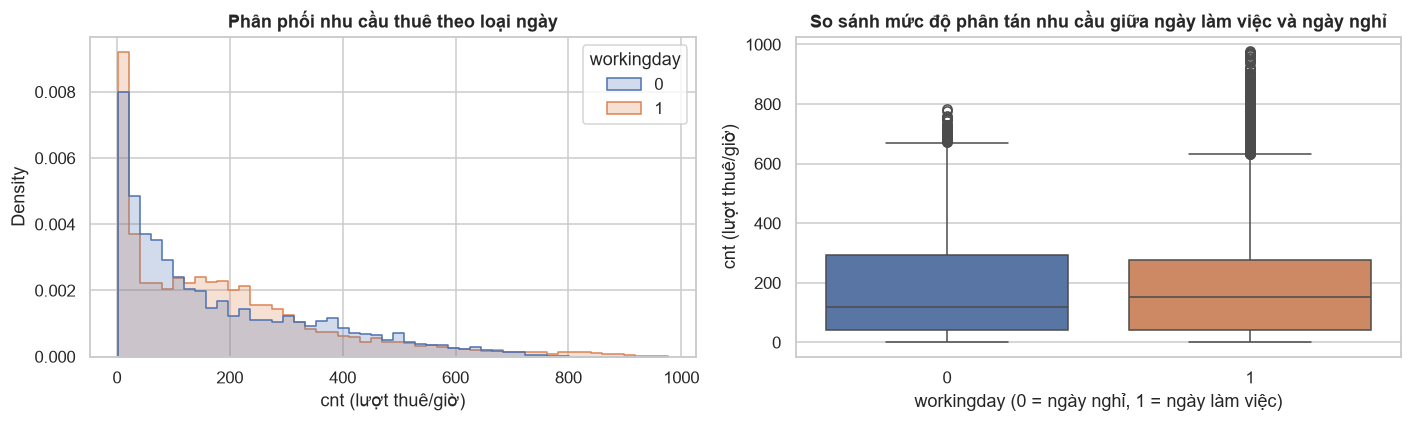

In [37]:
workingday_summary = df.groupby("workingday")["cnt"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
display(workingday_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="cnt", hue="workingday", bins=50, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Phân phối nhu cầu thuê theo loại ngày")
axes[0].set_xlabel("cnt (lượt thuê/giờ)")
sns.boxplot(data=df, x="workingday", y="cnt", hue="workingday", legend=False, ax=axes[1])
axes[1].set_title("So sánh mức độ phân tán nhu cầu giữa ngày làm việc và ngày nghỉ")
axes[1].set_xlabel("workingday (0 = ngày nghỉ, 1 = ngày làm việc)")
axes[1].set_ylabel("cnt (lượt thuê/giờ)")
plt.tight_layout()
plt.show()

In [38]:
fig.savefig("assets/Hinh2.5.png", dpi=180, bbox_inches="tight")

In [39]:
workingday_detail = df.groupby("workingday")["cnt"].agg(
    n="count",
    mean="mean",
    median="median",
    std="std",
    q1=lambda series: series.quantile(0.25),
    q3=lambda series: series.quantile(0.75),
    skewness="skew",
)
workingday_detail["IQR"] = workingday_detail["q3"] - workingday_detail["q1"]
display(workingday_detail[["n", "mean", "median", "std", "q1", "q3", "IQR", "skewness"]].round(2))

,n,mean,median,std,q1,q3,IQR,skewness
workingday,,,,,,,,
0,5514,181.41,119.0,172.85,40.0,292.0,252.0,1.06
1,11865,193.21,151.0,185.11,40.0,277.0,237.0,1.35


**Nhận xét Hình 2.5 và Bảng 2.3.** Hai nhóm đều có phân phối lệch phải và chồng lấn đáng kể. Ngày làm việc có mean 193.21 và median 151, cao hơn ngày nghỉ tương ứng là 181.41 và 119; tuy nhiên cả hai nhóm đều có độ phân tán lớn và đuôi phải.

Chênh lệch này chưa thể được diễn giải là tác động riêng của `workingday`, vì cơ cấu `hr`, mùa, năm và thời tiết trong hai nhóm không giống nhau. TV3 cần dùng Distribution Findings Sheet để quyết định kiểm định và báo cáo thêm effect size thay vì chỉ dựa vào chênh lệch mean.

## 2.6. Kết luận và hạn chế

### Kết luận chính

1. `cnt` là biến đếm lệch phải: mean 189.46 lớn hơn median 142.00, skewness bằng 1.2774 và variance/mean bằng 173.66.
2. Negative Binomial là lựa chọn hợp lý hơn Poisson để mô tả `cnt` vì vừa là phân phối đếm vừa cho phép over-dispersion; kết luận này được hỗ trợ bởi AIC/BIC, đồ thị và tỷ số variance/mean.
3. `log1p(cnt)` chỉ là phép kiểm tra hình dạng; nó không tự động đưa dữ liệu về Normal và không được chốt làm biến đổi cuối cùng cho TV5.
4. `temp` gần đối xứng và Beta có AIC thấp hơn Normal trong lần fit này; `hum` gần đối xứng và Normal có AIC thấp hơn Beta.
5. Ngày làm việc có mức `cnt` trung tâm cao hơn ngày nghỉ, nhưng hai phân phối chồng lấn nhiều và chưa thể suy ra tác động nhân quả.

### Hạn chế

- Goodness-of-fit nhạy với cỡ mẫu lớn; p-value rất nhỏ không đồng nghĩa sai khác có ý nghĩa thực tiễn lớn.
- Các quan sát theo giờ không độc lập hoàn toàn do tự tương quan, nên độ chắc chắn của các kiểm định có thể bị đánh giá quá cao.
- Phân phối `cnt` gộp nhiều cấu trúc theo giờ, workingday, năm, mùa và thời tiết; fit phân phối gộp không đại diện hoàn hảo cho từng nhóm.
- `temp` và `hum` ở thang chuẩn hóa 0–1; Beta được fit sau clipping kỹ thuật rất nhỏ tại biên và việc này phải được ghi rõ.

### Bàn giao cho các phần sau

- **TV3 / V-05:** `cnt` lệch phải và over-dispersion; khi chọn kiểm định cần kiểm tra giả định, cân nhắc test phi tham số và báo cáo effect size.
- **TV4 / V-06:** Pearson đo tuyến tính, Spearman phù hợp hơn khi quan hệ đơn điệu và chịu ảnh hưởng của lệch/ngoại lai; lựa chọn cuối cùng cần dựa trên phân phối chính thức.
- **TV5 / V-07:** chưa chốt biến đổi `cnt`; nếu thử log hoặc biến đổi khác, metric cuối phải quy về thang lượt thuê gốc.

## Distribution Findings Sheet — TV2 — v1 — DRAFT

- **Dữ liệu:** `EDA/cleaned_data/hour_cleaned.csv`, 17,379 dòng; phân tích `cnt`, `temp`, `hum`; so sánh thêm `cnt` theo `workingday`.
- **Phương pháp:** thống kê mô tả, histogram/KDE, ECDF, boxplot, Q–Q plot, Poisson, Negative Binomial, Normal, Log-normal và Beta; so sánh AIC/BIC và goodness-of-fit có cảnh báo mẫu lớn.
- **Kết quả:** `cnt` lệch phải và over-dispersion mạnh; Negative Binomial phù hợp hơn Poisson. `temp` có Beta thấp hơn Normal theo AIC; `hum` có Normal thấp hơn Beta theo AIC.
- **Quyết định:** giữ toàn bộ quan sát; không chốt `log1p(cnt)` làm biến đổi cuối cùng; các số liệu thời tiết giữ ở thang chuẩn hóa 0–1.
- **Downstream:** TV3 lưu ý lệch phải, over-dispersion và tính không độc lập; TV4 lưu ý lựa chọn Pearson/Spearman; TV5 chưa chốt biến đổi mục tiêu.
- **File liên quan:** `report.md`, `distribution_findings.md`, `README.md`.